<a href="https://colab.research.google.com/github/makenzieearle/Modeling-Probability-of-the-Schrodinger-Equation/blob/main/week-3/21_fault_tolerant_compilation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Fault-tolerant compilation needs a recent Qiskit -- the gridsynth synthesis ships in Qiskit 2.x.
%pip install -U qiskit
%pip install pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=aecbb183746b33a65cc478bb021bc9ebe38346e74b12090fc26a649fc4e54068
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Tolerate It

*Lab 21 — Fault-Tolerant Compilation*

## Objectives
* See <b>why</b> a fault-tolerant quantum computer forces us onto a small, *discrete* set of gates -- and why the standard choice is <b>Clifford + T</b>. This is the punchline of two famous theorems: Eastin&ndash;Knill and Gottesman&ndash;Knill.
* Write the dumbest compiler imaginable -- brute-force search -- and watch it drown in an exponential.
* Learn how the grown-ups do it: number-theory-based circuit synthesis (the Ross&ndash;Selinger *gridsynth* algorithm).
* Run a real `gridsynth` on an `Rz` + `CNOT` circuit and measure how the <b>T-count scales with the accuracy</b> $\varepsilon$.
* Do a back-of-the-envelope <b>resource estimate</b> in the only currency a fault-tolerant machine really cares about: T-gates.

This lab is built around Ross & Selinger, *Optimal ancilla-free Clifford+T approximation of z-rotations* ([arXiv:1403.2975](https://arxiv.org/abs/1403.2975)), and drives Qiskit's implementation of it. Prepared for QCIPU 2026.

## 1. Why Clifford + T?

Everything you've done so far has run gates on *bare* physical qubits. On a real fault-tolerant machine you don't get to do that. Your data lives in a <b>logical</b> qubit that is spread across many physical qubits by a quantum error-correcting code (like the repetition code from the error-correction lab). To *act* on that logical qubit, you have to act on the physical qubits in a way that doesn't let a single physical error quietly corrupt the whole code block.

The safest way to do that is a <b>transversal gate</b>: apply the same one-qubit gate to each physical qubit of the block in parallel. Because no two physical qubits in the block ever talk to each other, an error on one of them can't spread to the others. Transversal gates are the gold standard -- cheap and naturally fault-tolerant.

So which gates can we do transversally? Here's the catch, and it's a theorem:

<div class="alert alert-warning">

<b>Eastin&ndash;Knill theorem (2008).</b> No quantum error-correcting code that can detect errors has a <b>universal</b> set of transversal gates.

</div>

In other words, the set of gates you can do the easy, fault-tolerant way is always *discrete* and *non-universal*. You can never get every possible rotation for free. For many of the nicest codes (e.g. the Steane code) the transversal gates are exactly the <b>Clifford group</b> -- generated by the Hadamard $H$, the phase gate $S$, and the $CNOT$.

That sounds like a lot of gates. Is Clifford enough on its own? Let's check what is and isn't Clifford.

<p align="center">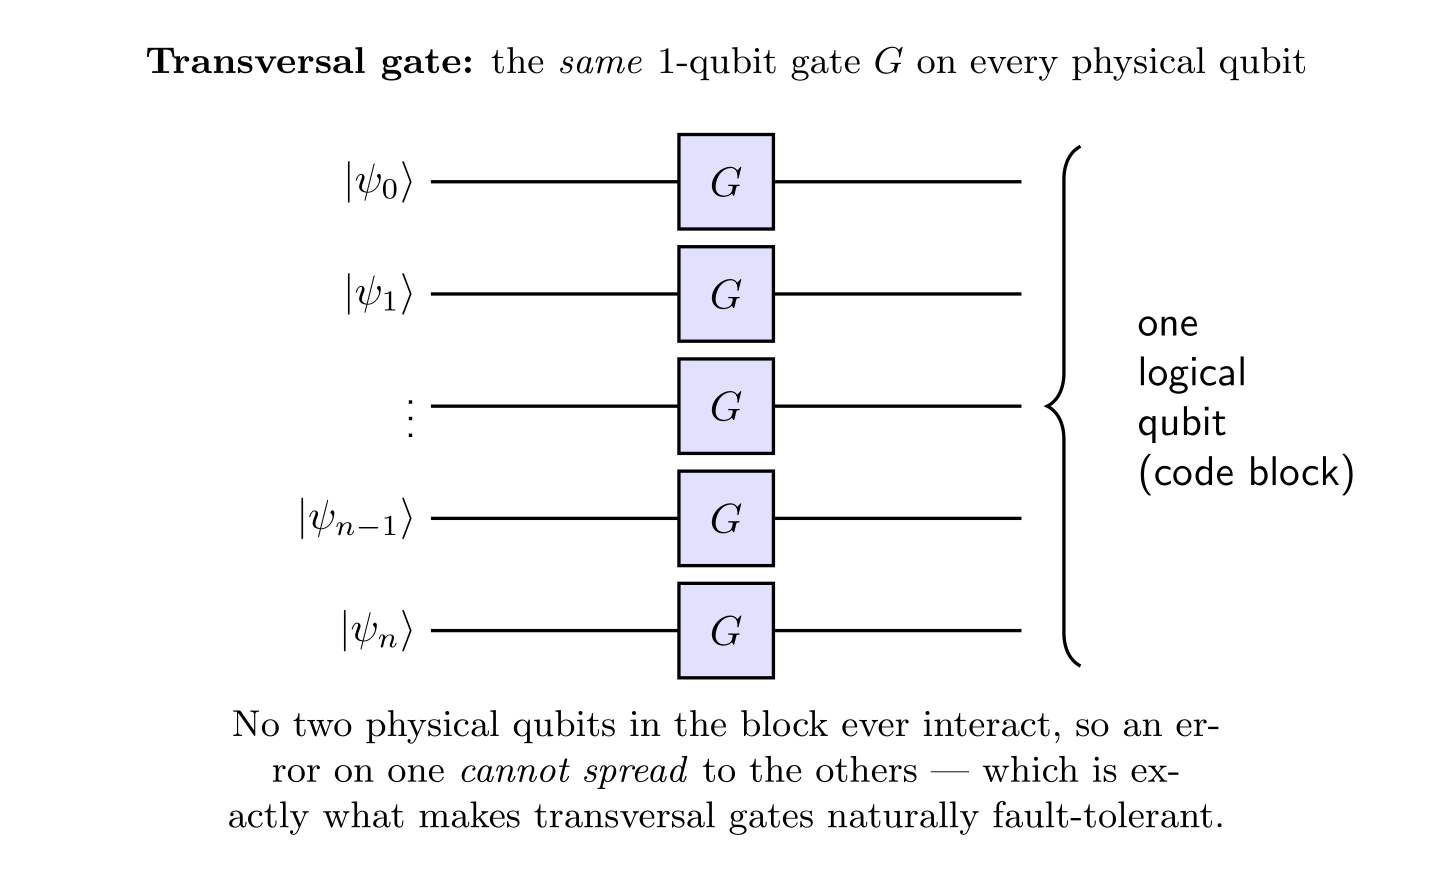</p>

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Clifford

def is_clifford(qc):
    # True iff Qiskit can build a stabilizer tableau from the circuit.
    try:
        Clifford(qc)
        return True
    except Exception:
        return False

for name in ['h', 's', 'sdg', 'x', 'z', 'cx', 't', 'tdg']:
    qc = QuantumCircuit(2)
    getattr(qc, name)(*([0, 1] if name == 'cx' else [0]))
    print(f"  {name:>3}:  Clifford = {is_clifford(qc)}")

    h:  Clifford = True
    s:  Clifford = True
  sdg:  Clifford = True
    x:  Clifford = True
    z:  Clifford = True
   cx:  Clifford = True
    t:  Clifford = False
  tdg:  Clifford = False


So $H$, $S$, $X$, $Z$, $CNOT$ are Clifford; the <b>$T$ gate</b> (a $45^\circ$ phase, $T=\mathrm{diag}(1, e^{i\pi/4})$) is <b>not</b>. Does that matter? You might hope a big pile of Clifford gates could approximate anything. It can't -- and here is the second theorem:

<div class="alert alert-warning">

<b>Gottesman&ndash;Knill theorem.</b> A circuit built <b>only</b> from Clifford gates (on computational-basis input, with computational-basis measurement) can be simulated <b>efficiently on a classical computer</b>.

</div>

If a classical laptop can simulate it, it can't be giving you a quantum speedup. Let's feel how strong that statement is &mdash; you build the demo. Make a <b>big</b> Clifford-only circuit and simulate it the smart way:

* Make a random Clifford on `n = 100` qubits with `random_clifford(n, seed=1989)`, and turn it into a circuit with `.to_circuit()`.
* Simulate it with `StabilizerState(qc)` -- this tracks the *stabilizer tableau*, never a state vector.
* Pull an expectation value out of the state, e.g. `state.expectation_value(Pauli('Z' + 'I'*(n-1)))` for $\langle Z_0\rangle$. Wrap the simulation in `time.perf_counter()` calls so you can see how long 100 qubits took.

In [7]:
import time
from qiskit.quantum_info import StabilizerState, random_clifford, Pauli

n = 100                                   # one hundred qubits
# your code here
cliff=random_clifford(n,seed=1989)
qc=cliff.to_circuit()
start=time.perf_counter()
state=StabilizerState(qc)
exp_z0=state.expectation_value(Pauli('Z' + 'I'*(n-1)))

dt = time.perf_counter() - start

print(f"Simulated a {n}-qubit, {qc.size()}-gate Clifford circuit in {dt:.2f}s")
print(f"<Z_0> = {exp_z0.real:.3f}")
print(f"A full state vector would need 2^{n} = {2**n:.2e} complex amplitudes.")

Simulated a 100-qubit, 9844-gate Clifford circuit in 0.12s
<Z_0> = 0.000
A full state vector would need 2^100 = 1.27e+30 complex amplitudes.


A state vector for 100 qubits would need $2^{100}\approx 10^{30}$ complex numbers -- vastly more than there are atoms in your body. Yet the stabilizer formalism simulated it on this machine in a fraction of a second, because Clifford circuits simply aren't using the full power of quantum mechanics. That's Gottesman&ndash;Knill, and it's *exactly* why Clifford gates alone can never beat a classical computer.

<div class="alert alert-warning">

<b>A warning worth pausing on.</b> All course long we've leaned on the rough idea that quantum advantage needs *lots* of qubits -- and 100 qubits is well past the $\sim 50$-qubit wall where honest state-vector simulation falls off a cliff, squarely in what *sounds* like "quantum-advantage territory." But we just simulated 100 qubits on a laptop, instantly. So take the lesson to heart: <b>a big qubit count is not, by itself, evidence of quantum advantage.</b> *What* you do with the qubits is what counts -- a circuit can be huge and still be classically trivial if it never leaves the Clifford group. The hardness lives in the non-Clifford ($T$) gates, which is exactly why the rest of this lab obsesses over them.

</div>

The fix is to add a single non-Clifford gate. Throw in the <b>$T$ gate</b> and the set <b>Clifford + T</b> becomes <b>universal</b>: by the Solovay&ndash;Kitaev theorem you can approximate *any* unitary as closely as you like with a long enough Clifford+T sequence.

But there's no free lunch. On a fault-tolerant machine the Clifford gates are the cheap transversal ones, while the $T$ gate is <b>expensive</b> -- it has to be supplied by a separate, costly "magic state distillation" factory. So the entire game of <b>fault-tolerant compilation</b> is:

> Rewrite the circuit you want into Clifford+T, using <b>as few $T$ gates as possible</b>, to hit a target accuracy $\varepsilon$.

The rest of this lab is about how to actually *do* that rewriting -- first the naive way, then the clever way.

Two theorems, one conclusion — the gate set is squeezed onto **Clifford + T**:

<p align="center">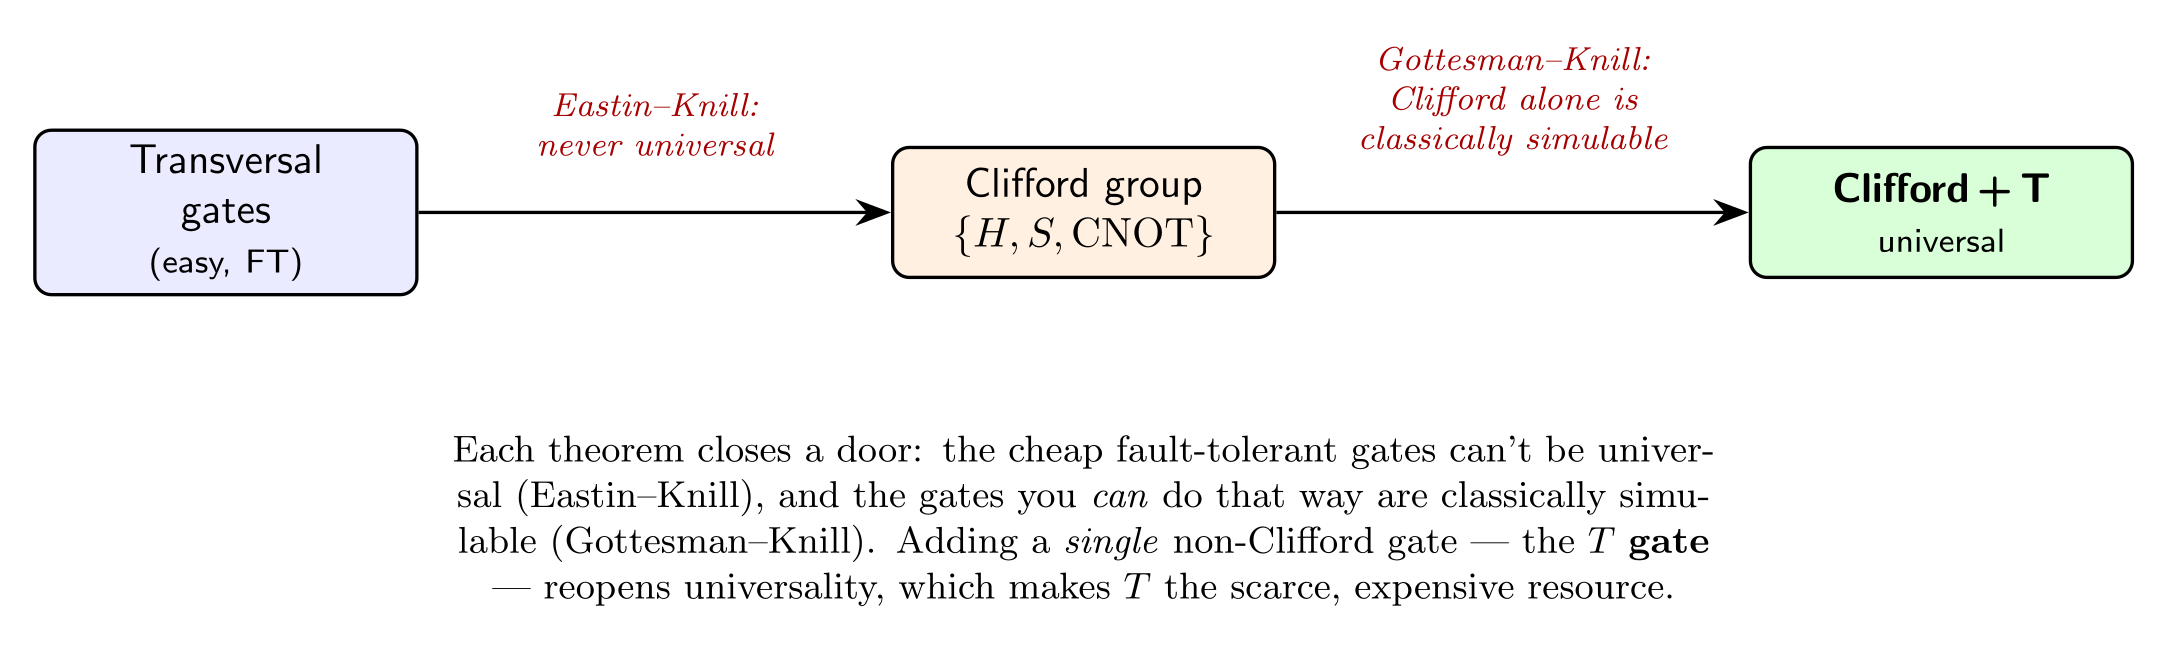</p>

## 2. Build the dumbest possible compiler

Solovay&ndash;Kitaev promises that *some* Clifford+T sequence approximates our rotation -- it just won't tell us which one. So here's the laziest strategy imaginable: generate every sequence and keep whichever one lands closest to the target. (It turns out $H$ and $T$ on their own already generate a dense subset of all single-qubit gates, up to a global phase, so we only need those two letters.)

You're going to build this compiler yourself, in small pieces. By the end you'll have something that genuinely *works* -- and then you'll watch it collapse under its own weight.

<b>Step 1 &mdash; the toolbox.</b> Set up the gates and the rotation we're chasing.

* Define the Hadamard `H` $=\tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ and the $T$ gate $=\mathrm{diag}(1,\,e^{i\pi/4})$ as $2\times2$ complex NumPy arrays.
* Collect them in a dict `GATES` so you can grab one by its letter, e.g. `GATES['H']`.
* Build `target`, the rotation $R_z(\theta)=\mathrm{diag}(e^{-i\theta/2},\,e^{i\theta/2})$ for the given `theta`.

In [10]:
import numpy as np

theta = 0.5     # the rotation angle we want to approximate
# your code here
H=np.array([[1,1],[1,-1]])/np.sqrt(2)
T=np.array([[1,0],[0,np.exp(1j*np.pi/4)]])
GATES={'H':H,'T':T}
target= np.array([[np.exp(-1j*theta/2),0],[0,np.exp(1j*theta/2)]])

<b>Step 2 &mdash; a ruler.</b> To say how close a candidate sequence is, we need a distance between two unitaries that <b>ignores an overall global phase</b> -- a global phase is physically invisible, so two unitaries that differ only by one should count as identical. That detail is easy to get wrong, so here it is, ready to use. You don't need to change it.

In [11]:
def distance(U, V):
    # Distance between two unitaries, ignoring an unobservable global phase.
    phase = np.vdot(V.flatten(), U.flatten())
    phase /= abs(phase)
    return np.linalg.norm(U - phase * V, 2)

<b>Step 3 &mdash; evaluate one sequence.</b> Write a function `word_to_unitary(word)` that takes a string of gate letters like `'HTTH'` and returns the $2\times2$ unitary you get by multiplying those gates together.

* Start from the identity, `np.eye(2, dtype=complex)`.
* Walk through the letters and multiply in `GATES[letter]` for each one.
* Sanity check: `word_to_unitary('HH')` should come back as (essentially) the identity, since $H^2 = I$.

In [12]:
def word_to_unitary(word):
    # your code here
    U=np.eye(2,dtype=complex)
    for letter in word:
        U=U@GATES[letter]
    return U

# sanity check -- should print the 2x2 identity:
print(np.round(word_to_unitary('HH'), 10))

[[ 1.+0.j -0.+0.j]
 [-0.+0.j  1.+0.j]]


<b>Step 4 &mdash; the search.</b> Now the compiler itself. Write `brute_force_best(length)` that tries <b>every</b> word of `H`s and `T`s of the given `length` and returns the smallest `distance` to `target` it can find -- and, handily, the winning word.

* `itertools.product('HT', repeat=length)` yields every word of that length, one tuple of letters at a time.
* Turn each one into a unitary with your `word_to_unitary`, measure its `distance` to `target`, and keep the best you've seen.
* Test it at `length = 6`.

Before you run it: how many words is it going to check at length $L$?

In [28]:
import itertools

def brute_force_best(length):
    best_dist, best_word = np.inf, None
    # your code here
    for word in itertools.product('HT',repeat=length):
        word=''.join(word)
        dist=distance(word_to_unitary(word),target)
        if dist<best_dist:
            best_dist=dist

    return best_dist, best_word

d, w = brute_force_best(6)
print(f"best length: '{L}'  (distance {d:.4f})")

best length: '14'  (distance 0.2493)


<b>Step 5 &mdash; watch it grow.</b> One length isn't a story. Sweep the word length upward and, at each length, record <b>both</b> the best error you can reach and how long the search took.

* Loop over `lengths`.
* Time each `brute_force_best` call (`time.perf_counter()` before and after).
* Append the best error to `errors` and the elapsed seconds to `times`.

(Printing the word count `2**L` each time makes the trend impossible to miss.)

In [36]:
import time

lengths = list(range(2, 15, 2))
errors, times = [], []
for L in lengths:
    # your code here
    time.perf_counter()
    d,w=brute_force_best(L)
    errors.append(d)
    times.append(time.perf_counter())
    time.perf_counter()
    print(f"best length: '{2**L}'  (distance {d:.4f})")
    dt = time.perf_counter()-start
    print(f"elapsed time: {dt:.4f} seconds")

best length: '4'  (distance 0.2493)
elapsed time: 1803.4886 seconds
best length: '16'  (distance 0.2493)
elapsed time: 1803.4963 seconds
best length: '64'  (distance 0.2493)
elapsed time: 1803.5262 seconds
best length: '256'  (distance 0.2493)
elapsed time: 1803.6697 seconds
best length: '1024'  (distance 0.1426)
elapsed time: 1803.9145 seconds
best length: '4096'  (distance 0.1426)
elapsed time: 1804.3565 seconds
best length: '16384'  (distance 0.1426)
elapsed time: 1806.0286 seconds


<b>Step 6 &mdash; see it.</b> Plot accuracy and cost side by side. (Provided -- just run it.)

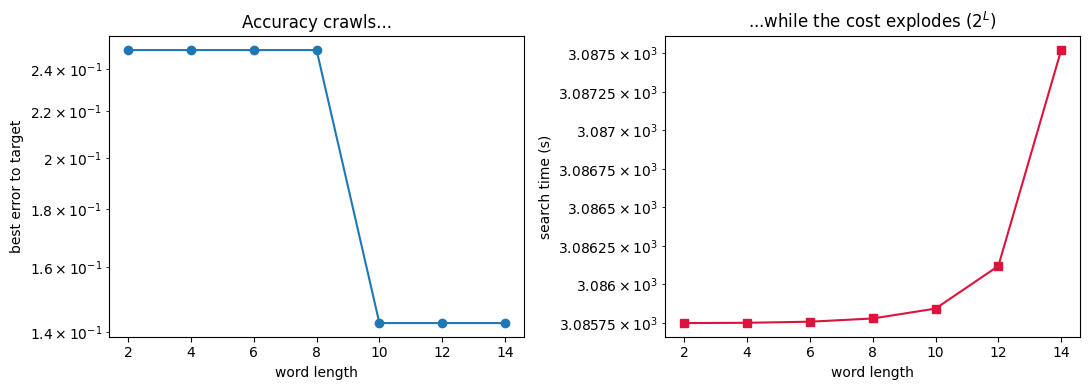

In [35]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(lengths, errors, 'o-')
ax1.set_xlabel('word length'); ax1.set_ylabel('best error to target')
ax1.set_title('Accuracy crawls...')
ax2.semilogy(lengths, times, 's-', color='crimson')
ax2.set_xlabel('word length'); ax2.set_ylabel('search time (s)')
ax2.set_title(r'...while the cost explodes ($2^L$)')
plt.tight_layout(); plt.show()

Look at what your own compiler just did. The number of words it must check is $2^L$, so every two extra letters <b>quadruples</b> the work -- the search time climbs a straight line on the log plot. Meanwhile the best achievable error barely budges; you claw down to about a tenth and then stall.

To reach a respectable $\varepsilon = 10^{-10}$ this way you'd need words hundreds of letters long -- $2^{200}$ candidates, more sequences than there are atoms in the observable universe. Brute force is utterly, hopelessly dead. There has to be a better way -- and there is.

## 3. How the grown-ups do it: number theory

The breakthrough is to stop *searching* and start *computing*. Two ideas make it work.

<b>Idea 1 -- exact synthesis (Kliuchnikov&ndash;Maslov&ndash;Mosca, 2012).</b> Not every single-qubit unitary can be written *exactly* in Clifford+T, but the ones that can have a beautiful fingerprint: every matrix entry is built out of just two ingredients -- the number $\tfrac{1}{\sqrt{2}}$ and $\omega = e^{i\pi/4}$. Concretely, each entry is an integer combination

$$ \frac{a_0 + a_1\,\omega + a_2\,\omega^2 + a_3\,\omega^3}{\sqrt{2}^{\,k}}, \qquad a_j \in \mathbb{Z}, $$

i.e. it lives in the ring $\mathbb{Z}[1/\sqrt{2},\, i]$ (note $\omega^2 = i$). If your target unitary is *in that ring*, there is a <b>polynomial-time algorithm with no searching at all</b>: you read off the integer $k$ (the "denominator exponent"), and that number tells you exactly which $H\cdot T^a$ layer to peel off the front; repeat, and the optimal Clifford+T word falls out. Compare that to Section 2 -- no exponential, no luck required.

<b>Idea 2 -- approximate synthesis (Ross&ndash;Selinger, 2014: *gridsynth*).</b> A generic rotation $R_z(\theta)$ is <b>not</b> in the ring (its entries $e^{\pm i\theta/2}$ are transcendental). So gridsynth first finds the ring element *closest* to $e^{-i\theta/2}$ to within $\varepsilon$ -- this is a 2-D lattice "grid problem," plus a number-theoretic (Diophantine) step -- and then hands that ring unitary to exact synthesis. The payoff is a provably near-optimal $T$-count of about

$$ N_T \;\approx\; 3\,\log_2\!\left(\frac{1}{\varepsilon}\right) $$

$T$ gates, which is optimal up to an additive constant. We won't reimplement the number theory here (it's a deep rabbit hole), but let's at least see the two ingredients the whole ring is built from.

In [37]:
# The two 'magic numbers' every Clifford+T matrix entry is built from:
print("1/sqrt(2)            =", 1/np.sqrt(2))
print("omega = e^(i*pi/4)   =", np.exp(1j*np.pi/4))
print("        (1 + i)/sqrt2 =", (1 + 1j)/np.sqrt(2), "  <- same thing")

w = np.exp(1j*np.pi/4)
print("\nPowers of omega (the four directions on the lattice):")
for p in range(4):
    print(f"  omega^{p} = {np.round(w**p, 6)}")

1/sqrt(2)            = 0.7071067811865475
omega = e^(i*pi/4)   = (0.7071067811865476+0.7071067811865475j)
        (1 + i)/sqrt2 = (0.7071067811865475+0.7071067811865475j)   <- same thing

Powers of omega (the four directions on the lattice):
  omega^0 = (1+0j)
  omega^1 = (0.707107+0.707107j)
  omega^2 = 1j
  omega^3 = (-0.707107+0.707107j)


## 4. Driving a real synthesizer: `gridsynth`

Qiskit ships a fast (Rust) implementation of gridsynth as `qiskit.synthesis.gridsynth_rz(angle, epsilon)`. It returns a one-qubit `QuantumCircuit` of Clifford+T gates approximating $R_z(\texttt{angle})$ to within `epsilon`.

Let's point it at the <b>very same</b> rotation we just brute-forced -- $R_z(0.5)$ -- but ask for real accuracy this time. Call `gridsynth_rz` on `theta` with `epsilon = 1e-2`, then draw the circuit and count its gates.

In [46]:
from qiskit.synthesis import gridsynth_rz

epsilon = 1e-2
# your code here
circ=gridsynth_rz(theta,epsilon)

print(circ.draw())
ops = circ.count_ops()
print("\ngate counts:", dict(ops))
print("T-count:", ops.get('t', 0) + ops.get('tdg', 0))
print("60 gates")

global phase: 5π/4
   ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
q: ┤ H ├┤ T ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├»
   └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«   ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«q: ┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ H ├┤ T ├»
«   └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«   ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
«q: ┤ S ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ S ├┤ H ├┤ T ├┤ S ├»
«   └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«   ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐
«q: ┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ X ├┤ S ├
«   └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘

gate counts: {'h': 23, 't': 22, 's': 12, 'x'

A real Clifford+T approximation just looks like a long *word*. Here is gridsynth's output for
$R_z(0.5)$ at $\varepsilon=10^{-2}$ — an alternating string of $H$, $T$ and $S$ (yours may differ
slightly). Only the $T$ boxes cost anything on a fault-tolerant machine; count them.

<p align="center">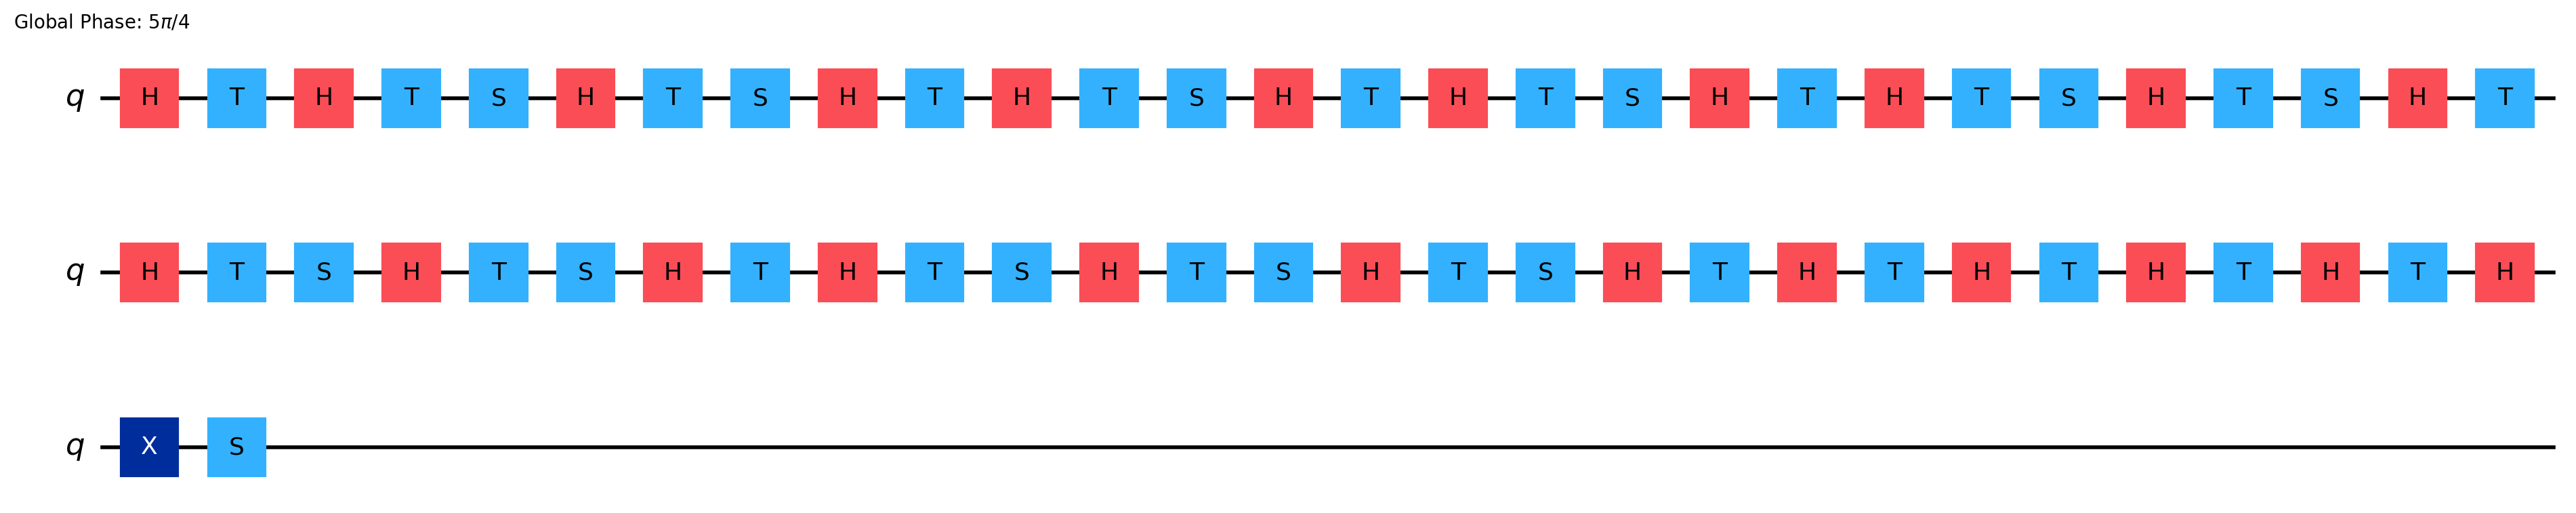</p>

Did it actually hit the accuracy it promised? Write `rz_error(circ, angle)` that measures how far the synthesized `circ` is from an ideal $R_z(\text{angle})$ -- using the <b>same</b> global-phase-blind idea you built into `distance` back in Section 2.

* Grab the two matrices: `Operator(circ).data` for your circuit, and `Operator(RZGate(angle)).data` for the ideal rotation.
* Return their distance -- you can reuse your `distance` function directly, since a global phase is just as invisible here as it was there.

In [49]:
from qiskit.quantum_info import Operator
from qiskit.circuit.library import RZGate
import numpy as np

def rz_error(circ, angle):
    U_circ = Operator(circ).data
    U_rz = Operator(RZGate(angle)).data

    # Note: U_rz and U_circ order for phase is V, U from original distance
    phase = np.vdot(U_rz.flatten(), U_circ.flatten())
    phase /= abs(phase)
    return np.linalg.norm(U_circ - phase * U_rz, 2)


print(f"target epsilon : {epsilon:.0e}")
print(f"actual error   : {rz_error(circ, theta):.2e}")

target epsilon : 1e-02
actual error   : 1.28e-03


<b>One practical wrinkle &mdash; and your next bit of code.</b> The synthesizer under the hood (`rsgridsynth`) is young, and on some inputs at *loose* tolerances it throws an internal `panicked` error instead of an answer. Wrapping flaky research tooling in a defensive retry is a genuinely useful habit, so you'll write that wrapper now.

Write `safe_gridsynth_rz(angle, epsilon, max_retries=20)` so that:

* It tries `gridsynth_rz(angle, eps)` and, if that succeeds, returns the circuit.
* If the call <b>fails</b>, it doesn't give up: shrink `eps` a little (say `eps *= 0.8`) and try again, up to `max_retries` times. Asking for a *tighter* tolerance only makes the answer better, so you're still honouring the `epsilon` the caller asked for.
* If it's still failing after `max_retries` tries, `raise` an error instead of looping forever.

<b>One catch &mdash; literally.</b> This failure is a *Rust* panic that Python surfaces as a `PanicException`, and that class lives <b>outside</b> the usual `Exception` family (it sits next to things like `KeyboardInterrupt`). A plain `except Exception` sails right past it &mdash; you need `except BaseException`. Try the narrower `except Exception` first if you want to watch it fail to catch.

(If the headline call earlier ever crashes with a `panicked` message after you change the angle, this wrapper is the fix.)

In [75]:
from qiskit.synthesis import gridsynth_rz
from qiskit.exceptions import QiskitError

def safe_gridsynth_rz(angle, epsilon, max_retries=20):
    eps = epsilon
    for i in range(max_retries):
        try:
            circ = gridsynth_rz(angle, eps)
            eps *= .08
            return circ
        except BaseException:
            print("Error")



# sanity check -- a normal request should sail through:
print("safe call ok, gate counts:", dict(safe_gridsynth_rz(0.167, 1e-1).count_ops()))
# (To see the retry actually kick in, try a troublemaker like safe_gridsynth_rz(0.167, 1e-1):
#  you'll see red 'panicked' text scroll by from the failed tries, but still get a circuit back.)

safe call ok, gate counts: {'h': 11, 't': 10, 's': 8, 'x': 1}


In a few milliseconds, gridsynth beat what hours of brute force could never reach. And not every rotation costs the same: some angles are <b>exactly</b> in the ring (Section 3), so they synthesize for free no matter how small you make $\varepsilon$, while generic angles get more expensive as you demand more accuracy.

See it for yourself. For each of the two angles below, use your `safe_gridsynth_rz` to synthesize it at a range of tolerances (say `[1e-2, 1e-4, 1e-6, 1e-8]`) and record the T-count each time (from `count_ops()`, add up `'t'` and `'tdg'`). Collect the four T-counts into `counts` so the line below prints them.

In [78]:
for angle, label in [(np.pi/4, "pi/4  (= T exactly, in the ring)"),
                     (0.5,      "0.5   (generic, must be approximated)")]:
    counts = []
    # your code here
    safe_gridsynth_rz(angle, 1e-2)
    counts.append(safe_gridsynth_rz(angle, 1e-4))
    counts.append(safe_gridsynth_rz(angle, 1e-6))
    counts.append(safe_gridsynth_rz(angle, 1e-8))


    print(f"{label:36s} T-count @ eps[1e-2..1e-8] = {counts}")

pi/4  (= T exactly, in the ring)     T-count @ eps[1e-2..1e-8] = [<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17a5bfa5a0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17c31d2060>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17a5bfb1a0>]
0.5   (generic, must be approximated) T-count @ eps[1e-2..1e-8] = [<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17a5cfee40>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17a5e91f40>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7e17a5e90bc0>]


$R_z(\pi/4)$ is just the $T$ gate up to a global phase, so it stays at a flat <b>1</b> $T$ no matter how tight $\varepsilon$ is. The generic angle climbs steadily. That climb is the heart of the next section.

## 5. Compiling a real circuit: how the T-cost scales with $\varepsilon$

Real circuits aren't a single rotation. A typical workload -- say one Trotter step of a spin Hamiltonian, or a layer of a variational ansatz -- is a stack of single-qubit $R_z$ rotations stitched together with $CNOT$s. The $CNOT$s are already Clifford (free), so <b>all</b> the $T$-cost comes from synthesizing the $R_z$ angles.

<b>Your job:</b> write `cliffordT_compile(circ, epsilon)` that returns a <b>new</b> circuit in which every `rz` has been swapped for its Clifford+T approximation, with the Clifford gates carried over untouched. A few Qiskit pointers:

* Start a fresh `QuantumCircuit(circ.num_qubits)` to build into.
* Iterate with `for instr in circ.data:` -- each `instr` carries `instr.operation` (the gate) and `instr.qubits` (the qubits it acts on). Turn a qubit into its integer index with `circ.find_bit(q).index`.
* If `instr.operation.name == 'rz'`, synthesize it: feed its angle, `instr.operation.params[0]`, to your `safe_gridsynth_rz`, then drop the little result circuit onto your output with `out.compose(little_circuit, [qubit_index], inplace=True)`.
* Any other gate is already Clifford -- copy it across unchanged with `out.append(instr.operation, qubit_indices)`.
* Return the finished circuit.

In [ ]:
def cliffordT_compile(circ, epsilon):
    # Returns a NEW circuit: every rz -> its gridsynth Clifford+T approximation,
    # every other (Clifford) gate copied over unchanged.
    out = QuantumCircuit(circ.num_qubits)
    # your code here
    ???
    return out

Now build a small test circuit: on `n_qubits` qubits, put each qubit into superposition with an $H$, apply a $z$-rotation by a random angle to each, then entangle neighbours with a chain of $CNOT$s. Build the circuit `raw`.

In [ ]:
rng = np.random.default_rng(2026)
n_qubits = 4
angles = rng.uniform(0, 2*np.pi, size=n_qubits)

raw = QuantumCircuit(n_qubits)
# your code here
???

print(raw.draw())
print("rz gates in the raw circuit:", raw.count_ops().get('rz', 0))

Finally, the experiment. Sweep $\varepsilon$ from $10^{-5}$ down to $10^{-12}$ (we stay in the tight-tolerance range where the synthesizer is rock-solid), compile `raw` at each accuracy, and record the <b>total</b> $T$-count. Then plot the $T$-count against $\log_2(1/\varepsilon)$ -- the number of *bits* of accuracy you're demanding. Fill in the three lines that compile and count.

In [ ]:
epsilons = [10.0**(-k) for k in range(5, 13)]
tcounts = []
for eps in epsilons:
    # your code here
    ???
    print(f"eps {eps:.0e}:  total T-count = {tcounts[-1]}")

bits = [np.log2(1/e) for e in epsilons]
n_rz = raw.count_ops().get('rz', 0)

plt.figure(figsize=(7, 4))
plt.plot(bits, tcounts, 'o-', label='measured (gridsynth)')
plt.plot(bits, [3 * b * n_rz for b in bits], '--',
         label=r'$3\,\log_2(1/\varepsilon)\times N_{rz}$ (theory)')
plt.xlabel(r'bits of accuracy  $\log_2(1/\varepsilon)$')
plt.ylabel('total T-count')
plt.title('T-count grows LINEARLY in the bits of accuracy')
plt.legend(); plt.tight_layout(); plt.show()

There it is: the $T$-count is a <b>straight line</b> in $\log_2(1/\varepsilon)$, with a slope of roughly $3$ per rotation. Squaring your accuracy (doubling the bits) costs only a fixed *additive* batch of $T$ gates per rotation -- not a doubling, not an explosion. That linear-in-log scaling is the Ross&ndash;Selinger guarantee, and it's what makes fault-tolerant compilation actually practical. Hold this plot next to the exponential wall from Section 2.

## 6. Resource estimation: counting what actually costs you

On a fault-tolerant machine the Clifford gates are basically free, but every $T$ gate has to be fed a freshly *distilled magic state* from a factory that eats a large block of physical qubits and many clock cycles. So we don't budget circuits in "number of gates" -- we budget them in:

* <b>$T$-count</b> -- the total number of $T$ gates, which sets how many magic states you must distill.
* <b>$T$-depth</b> -- the number of *layers* that contain a $T$ gate, which (if you can distill magic states in parallel) sets the wall-clock runtime.

Write a `resources(circ)` function that returns the $T$-count, the $T$-depth, and the total gate count, then run it on the circuit compiled to $\varepsilon = 10^{-6}$.

(Hint: `circ.depth(lambda instr: instr.operation.name in ('t', 'tdg'))` measures $T$-depth -- `depth` counts only the layers where its filter returns `True`.)

<p align="center">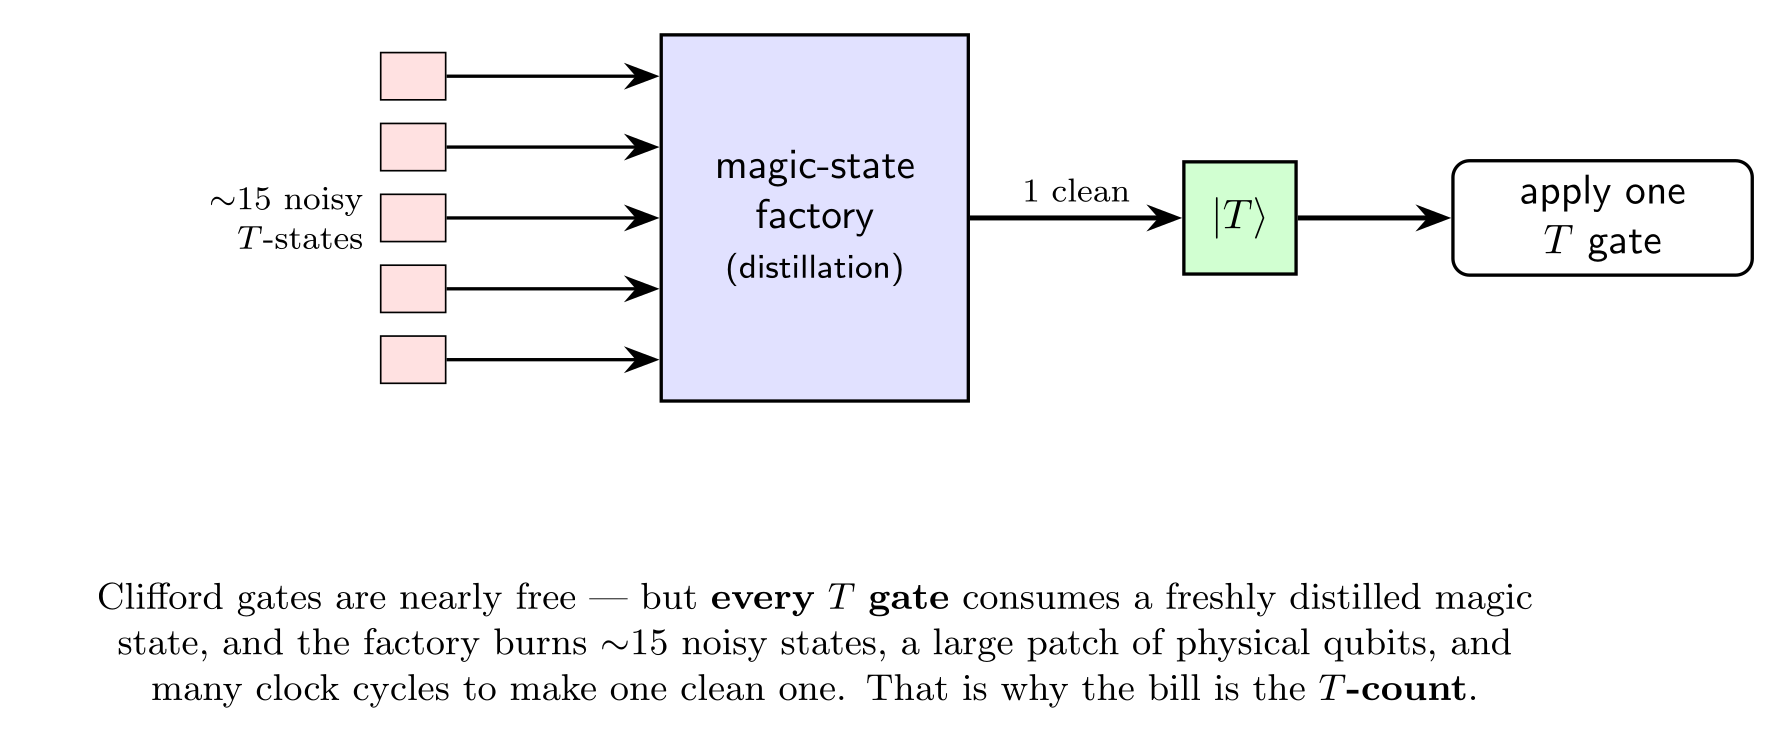</p>

In [ ]:
def resources(circ):
    "Return (T-count, T-depth, total gate count) for a compiled circuit."
    # your code here
    ???

eps = 1e-6
compiled = cliffordT_compile(raw, eps)
tcount, tdepth, total = resources(compiled)

print(f"resource estimate at epsilon = {eps:.0e}")
print(f"  total gates                  : {total}")
print(f"  T-count                      : {tcount}")
print(f"  T-depth                      : {tdepth}")
print(f"  fraction of gates that are T : {tcount/total:.1%}")

Now put a (very rough) price tag on it. Suppose, as a ballpark, that distilling one good magic state takes about $15$ raw $T$-states and a sizeable patch of the chip for one distillation round. Multiply your $T$-count by that and you get a feel for the staggering overhead hiding behind a circuit that looked tiny on paper. Try it, and try bumping `n_qubits` up or stacking a few Trotter layers to see how the estimate grows.

In [ ]:
states_per_T = 15                      # crude 15-to-1 distillation factor
magic_states = tcount * states_per_T
print(f"~{magic_states:,} distilled magic states needed for this one little circuit at eps=1e-6.")
print(f"And nearly every layer ({tdepth} of them) is gated on a fresh magic state arriving in time.")
print("\nThat overhead is *the* reason fault-tolerant quantum computing is hard --")
print("and the reason minimizing T-count is the whole point of fault-tolerant compilation.")

---

## 7. Open exploration: the price of *your* rotation

Sections 1–6 each had a single right answer. **This one does not.** Every rotation angle an
algorithm might call for has its *own* fault-tolerant price — and across the class those prices
will turn out to vary enormously. You're each going to measure the cost of a **different** angle,
post it on the whiteboard we know and love in the crossover, and only once the whole board is filled in will the pattern jump
out at you.

You'll be handed an angle from your own seed (set it below). You don't know anything about it yet —
that's the point. Measure it, post it, and we'll make sense of the board together.

In [ ]:
import hashlib

def assign_angle(seed):
    "Map your seed (your initials, or a number your instructor assigns) to a rotation angle."
    h = int(hashlib.sha256(str(seed).encode()).hexdigest(), 16)
    r = ((h >> 16) % 10**6) / 10**6
    pick, k = h % 10, 1 + (h >> 4) % 7
    if pick == 0:
        a = k * np.pi / 4
    elif pick == 1:
        a = k * np.pi / 4 + (0.004 + 0.02 * r) * (1 if (h >> 3) & 1 else -1)
    else:
        a = 0.05 + r * (2 * np.pi - 0.1)
    return float(a % (2 * np.pi))

def count_T(circ):
    "Total T gates (t + tdg) in a circuit."
    o = circ.count_ops()
    return o.get('t', 0) + o.get('tdg', 0)

**Build `study_angle`.** This is the measurement you'll run on your angle. Given an angle and a
list of target accuracies `eps_list`, it works out how the $T$-count grows as you demand more
precision, and boils that down to a single number — the **slope**. The steps:

1. Convert each tolerance to **bits of accuracy**: `bits = log2(1/eps)` (use `np.log2` over the list).
2. For each `eps`, synthesize the angle with your `safe_gridsynth_rz` and record its $T$-count with
   the provided `count_T`. Collect these into an array `tcounts`.
3. Fit a line of `tcounts` against `bits` with `np.polyfit(bits, tcounts, 1)` — the first number it
   returns is the **slope** ($T$ gates per bit), the second is the intercept.
4. Return a `dict` with at least `angle`, `bits`, `tcounts`, `slope`, and `intercept`.

In [ ]:
def study_angle(angle, eps_list=(1e-4, 1e-6, 1e-8, 1e-10, 1e-12)):
    "Measure how the T-count of Rz(angle) grows with accuracy; return the trend."
    # your code here
    ???

In [ ]:
SEED = "your-name-here"    # <-- set this to your name/initials, or the number you were assigned
my_angle = assign_angle(SEED)
print(f"your angle = {my_angle:.4f} rad = {my_angle/np.pi:.4f} * pi")

res = study_angle(my_angle)
magic_states = res["tcounts"][-1] * 15      # 15-to-1 distillation, at the tightest accuracy
print(f"  slope          : {res['slope']:.2f}  T gates per bit of accuracy")
print(f"  T @ eps=1e-12  : {res['tcounts'][-1]}")
print(f"\n  >>> WHITEBOARD ROW:  seed={SEED!r}  angle={my_angle:.4f}  slope={res['slope']:.2f}  "
      f"T@1e-12={res['tcounts'][-1]}  magic_states={magic_states:,}")

plt.figure(figsize=(5.5, 4))
plt.plot(res["bits"], res["tcounts"], "o-")
plt.xlabel("bits of accuracy  $\\log_2(1/\\varepsilon)$"); plt.ylabel("T-count")
plt.title(f"Your angle {my_angle:.3f}: T-count vs accuracy")
plt.tight_layout(); plt.show()

**Post your `WHITEBOARD ROW`** — seed, angle, slope, $T$-count, magic-state cost — on the whiteboard with everyone else's, and sort it by $T$-count once it's full. Then run the cell below to see the whole
landscape your dots were sampling.

In [ ]:
# Reference: the cost of every angle (run once the whiteboard is populated).
sweep = np.linspace(0.02, 2 * np.pi - 0.02, 140)
tc = np.array([count_T(safe_gridsynth_rz(a, 1e-10)) for a in sweep])
plt.figure(figsize=(7.2, 4.2))
plt.plot(sweep, tc, ".", ms=5)
plt.xlabel("rotation angle (rad)"); plt.ylabel("T-count at $\\varepsilon = 10^{-10}$")
plt.title("Cost of every angle: the landscape your dots are sampling")
plt.tight_layout(); plt.show()
print("Most angles cost ~100 T. A handful cost almost nothing. Where, exactly, are those?")

### Discuss

Read the board and the landscape together:

* **The slope.** Almost everyone's slope landed near the *same* value (~3 $T$ per bit). Why should
  the **rate** of growth be universal, no matter which angle you drew? (Section 3 holds the answer —
  Ross&ndash;Selinger.)
* **The jackpots.** A few angles cost essentially nothing, and stay **flat** as you tighten
  $\varepsilon$. What is special about *those* particular angles? (Look at where they sit on the
  axis, and recall what is *exactly* representable in Clifford + T.)
* **The near-misses.** Find two people whose angles are almost identical but whose costs differ by
  ~100$\times$. What does that say about how forgiving the ring is — is "close" ever good enough?
* **The bill.** Multiply the cheapest and the most expensive angle's $T$-count by the 15$\times$
  magic-state factor. In a real algorithm stuffed with rotations, why is **choosing your angles** —
  or recompiling to dodge the generic ones — worth real engineering effort?

## Wrap-up

You just walked the entire arc of fault-tolerant compilation:

1. Error correction forces you onto a discrete, non-universal transversal gate set (<b>Eastin&ndash;Knill</b>), and Clifford alone is classically simulable (<b>Gottesman&ndash;Knill</b>) -- so you settle on <b>Clifford + T</b>, with $T$ as the precious resource.
2. Brute-force synthesis is exponentially hopeless.
3. Number theory turns synthesis into a fast, no-search computation over the ring $\mathbb{Z}[1/\sqrt{2}, i]$.
4. `gridsynth` does this for real, with a near-optimal $T$-count.
5. The $T$-count of a circuit scales *linearly in the bits of accuracy*, $N_T \approx 3\log_2(1/\varepsilon)$ per rotation.
6. On a fault-tolerant machine, the bill is paid in $T$-count and $T$-depth -- which is why every serious compiler fights to shave $T$ gates.
7. And there is no single price for "a rotation": the cost depends on the *angle* itself -- a rare few are free, while a generic angle pays the full $\sim\!3\log_2(1/\varepsilon)$ tax. Choosing and compiling angles well is itself part of the craft.

### Further reading
* Eastin & Knill, *Restrictions on transversal encoded quantum gate sets*, [arXiv:0811.4262](https://arxiv.org/abs/0811.4262)
* Gottesman, *The Heisenberg representation of quantum computers*, [arXiv:quant-ph/9807006](https://arxiv.org/abs/quant-ph/9807006)
* Kliuchnikov, Maslov & Mosca, *Fast and efficient exact synthesis of single-qubit unitaries generated by Clifford and T gates*, [arXiv:1206.5236](https://arxiv.org/abs/1206.5236)
* Ross & Selinger, *Optimal ancilla-free Clifford+T approximation of z-rotations*, [arXiv:1403.2975](https://arxiv.org/abs/1403.2975)